In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.6 MB/s eta 0:00:0000:01


In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz


In [16]:
folder_path = "/kaggle/input/datasets/paultimothymooney/blood-cells/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL/"

image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpeg')]
img = cv2.imread(os.path.join(folder_path, image_files[0]))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Reshape pixels for clustering
pixel_values = lab.reshape((-1, 3))
pixel_values = np.float32(pixel_values)


In [17]:
k = 3  

kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(pixel_values)


segmented_kmeans = labels_kmeans.reshape(img.shape[:2]) 


data = pixel_values.T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data, c=k, m=2, error=0.005, maxiter=1000, init=None
)

labels_fcm = np.argmax(u, axis=0)


segmented_fcm = labels_fcm.reshape(img.shape[:2])

plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

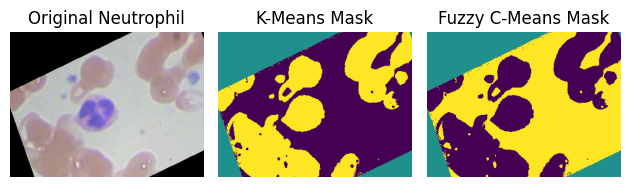

KMeans pixel count per cluster:
[34929 14544 27327]

FCM pixel count per cluster:
[27469 14544 34787]


In [18]:



plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Neutrophil")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_kmeans, cmap='viridis')
plt.title("K-Means Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_fcm, cmap='viridis')
plt.title("Fuzzy C-Means Mask")
plt.axis("off")

plt.tight_layout()
plt.show()
print("KMeans pixel count per cluster:")
print(np.bincount(labels_kmeans))

print("\nFCM pixel count per cluster:")
print(np.bincount(labels_fcm))